In [1]:
import torch
import numpy as np
import open3d as o3d
import os
from glob import glob
import subprocess
import copy
from scipy.spatial.transform import Rotation as sciR
import matplotlib.pyplot as plt
from pytorch3d.ops.knn import knn_gather, knn_points

def hat(phi):
    phi_x = phi[..., 0]
    phi_y = phi[..., 1]
    phi_z = phi[..., 2]
    zeros = torch.zeros_like(phi_x)

    phi_hat = torch.stack([
        torch.stack([zeros, -phi_z,  phi_y], dim=-1),
        torch.stack([phi_z,  zeros, -phi_x], dim=-1),
        torch.stack([-phi_y,  phi_x,  zeros], dim=-1)
    ], dim=-2)
    return phi_hat

def ExpSO3(phi, eps=1e-4):
    theta = torch.norm(phi, dim=-1)
    phi_hat = hat(phi)
    E = torch.eye(3, device=phi.device)
    coef1 = torch.zeros_like(theta)
    coef2 = torch.zeros_like(theta)

    ind = theta < eps

    # strict
    _theta = theta[~ind]
    coef1[~ind] = torch.sin(_theta) / _theta
    coef2[~ind] = (1 - torch.cos(_theta)) / _theta**2

    # approximate
    _theta = theta[ind]
    _theta2 = _theta**2
    _theta4 = _theta**4
    coef1[ind] = 1 - _theta2/6 + _theta4/120
    coef2[ind] = .5 - _theta2/24 + _theta4/720

    coef1 = coef1[..., None, None]
    coef2 = coef2[..., None, None]
    return E + coef1 * phi_hat + coef2 * phi_hat @ phi_hat

def drct_rotation(drct):
    B,P = drct.shape[0], drct.shape[1]
    drct_n = drct / torch.norm(drct, dim=-1, keepdim=True)
    dummy = torch.tensor([[[0.,0.,1.]]], device=drct.device)#1,1,3
    inner = torch.clamp((drct_n * dummy).sum(-1), min=-1, max=1)
    theta = torch.acos(inner)#B,P
    cross_drct = torch.cross(dummy, drct_n, dim=-1)
    cross_drct /= torch.norm(cross_drct,dim=-1,keepdim=True)#B,P,3
    pos_r = ExpSO3(cross_drct * theta.unsqueeze(-1))
    pos_dummy = torch.einsum('bpij, bpjk -> bpik', pos_r, dummy.unsqueeze(-1))
    pos_distance = torch.norm(pos_dummy.squeeze(-1) - drct_n, dim=-1)
    neg_r = ExpSO3(-cross_drct * theta.unsqueeze(-1))
    neg_dummy = torch.einsum('bpij, bpjk -> bpik', neg_r, dummy.unsqueeze(-1))
    neg_distance = torch.norm(neg_dummy.squeeze(-1) - drct_n, dim=-1)

    ret = []
    for b in range(B):
        for p in range(P):
            if neg_distance[b,p] < pos_distance[b,p]:
                ret.append(neg_r[b,p])
            else:
                ret.append(pos_r[b,p])
    ret = torch.stack(ret, dim=0).reshape(B,P,3,3)
    return ret

def capture_image(w,h,z,f,l,u, objects, out_file):
    vis = o3d.visualization.Visualizer()
    vis.create_window(width = w, height = h, visible=False)
    for obj in objects:
        vis.add_geometry(obj)
    ctr = vis.get_view_control()
    ctr.set_zoom(z)
    ctr.set_front(np.array(f))
    ctr.set_lookat(np.array(l))
    ctr.set_up(np.array(u))
    vis.capture_screen_image(out_file, do_render=True)
    del ctr
    del vis
    return

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


SYN dataset viz

In [3]:
file_idx = [str(i) + '.pt' for i in range(1500)]
file_dir = 'data/pc/full/laptop_h/train/'
#shape variance index (Eyeglasses Full Train)
#1**, 3**, 10**, 12**
#,*89,*10, *91, 09

#pipeline input
#699.， 1299， 1395 (laptop_h) 
#699, 1200, 850
i =850

file = torch.load(file_dir + file_idx[i])
#for k in file.keys():
#    print(k, file[k].shape)


In [4]:
pc = file['pc']
label = file['label']
joint, drct, angl = file['part_pv_point'], file['part_axis'], file['part_angles']
pose = file['pose_segs']
print(angl / torch.pi * 180)

joints, coors = [], []
for i in range(joint.shape[0]):
    joint_rotation = drct_rotation(drct.unsqueeze(0)).squeeze(0)
    j = o3d.geometry.TriangleMesh.create_arrow(cylinder_radius=0.005, cone_radius=0.01, cylinder_height=0.35, cone_height=0.05)
    j.rotate(joint_rotation[i], [0,0,0])
    j.translate(joint[i])
    j.paint_uniform_color([0.25,0.25,0.25])
    joints.append(j)

for i in range(pose.shape[0]):
    c = o3d.geometry.TriangleMesh.create_coordinate_frame(0.15)
    c.rotate(pose[i,:3,:3], [0,0,0])
    c.translate(pose[i,:3,-1])
    '''
    if i == 0:
        c.paint_uniform_color([1,0.5,0.5])
    elif i == 1:
        c.paint_uniform_color([0.5,1,0.5])
    else:
        c.paint_uniform_color([0.5,0.5,1])
    '''
    coors.append(c)

coors[0].translate(-0.15*pose[0,:3,0])
coors[1].translate(0.05*pose[0,:3,1])
coors[1].translate(0.2*pose[0,:3,0])

color = torch.ones_like(pc) * 0.75
color[label==0,0], color[label==0,1], color[label==0,2] = 1,0,0
color[label==1,0], color[label==1,1], color[label==1,2] = 0,1,0
#color[:,1] = 1
pcl = o3d.geometry.PointCloud()
pc = pose[0,:3,:3].transpose(1,0) @ (pc.transpose(1,0) - joint[0].reshape(3,1))
pc = (pc + joint[0].reshape(3,1)).transpose(1,0)
#pc[:,1] *=0.70
joints[0].rotate(pose[0,:3,:3].transpose(1,0), joint[0])
pcl.points = o3d.utility.Vector3dVector(pc)
pcl.colors = o3d.utility.Vector3dVector(color)

origin = o3d.geometry.TriangleMesh.create_coordinate_frame(0.11)
#o3d.visualization.draw_geometries([pcl, *coors, *joints, origin])
o3d.visualization.draw_geometries(
    [pcl],
    width=1280,
    height=960,
    zoom=1.35,
    front=[0.17419171639901809, 0.85892197414997573, 0.4815706472162446],
    lookat=[ 0.26964245297545486, -0.015964884360374573, -0.1484892497764928 ],
    up=[0.98467946754500113, -0.14797456574180615, -0.092248978795522699 ],
                                  )

tensor([0.])


In [12]:
pcl_r = copy.deepcopy(pcl)

In [15]:
pcl_g = copy.deepcopy(pcl)

In [16]:
o3d.visualization.draw_geometries(
    [pcl_r, pcl_g],
    width=1280,
    height=960,
    zoom=1.5,
    front=[0.14564994049355651, 0.86671687441047696, 0.47706179311107799],
    lookat=[0.11399857031985922, 0.0009743103459319331, -0.0048371151977387441 ],
    up=[ 0.98933423436770429, -0.12663916235663311, -0.071974268080189058 ],
                                  )

Real dataset viz

In [156]:
f = np.load('data/pc/real/laptop_output/train/hp_acn/60_box/input_2/1702990423.948055975.npz', allow_pickle=True)['arr_0'].item()
f.keys()

dict_keys(['pc', 'color', 'detection', 'segmentation', 'part', 'joint'])

In [157]:
o3d_pc = o3d.geometry.PointCloud()
choise = np.random.choice(f['pc'].shape[0], 100000, replace=True)
o3d_pc.points = o3d.utility.Vector3dVector(f['pc'][choise])
#o3d_pc.paint_uniform_color([0.5,0.5,0.5])
o3d_pc.colors = o3d.utility.Vector3dVector(0.75*f['color'][choise])

o3d.visualization.draw_geometries([o3d_pc])

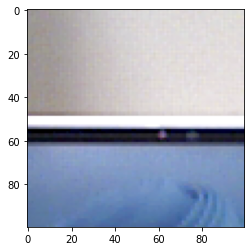

In [158]:
c = f['color'].reshape(480,640,3)
d = f['pc'].reshape(480,640,3)[:,:,-1]
d[d == 0] = -8.4
seg = f['segmentation'].reshape(480,640,1)
det = np.asarray(f['detection'].reshape(480,640,1), dtype=np.int32)

c = c[100:200, 210:310]
det = det[100:200, 210:310]
d = d[100:200, 210:310]
plt.imshow(c)
plt.imsave('det.jpg',0.5*det.repeat(3,2)+0.5*c)
plt.imsave('rgb.jpg',c)
plt.imsave('dep.jpg',d)

In [159]:
seg = f['segmentation']
det = seg != 0
#det = f['detection']

pc = f['pc'][det>0,:]
color = f['color'][det>0,:]
seg = seg[det>0]
joint, drct = f['joint'][0,:3], f['joint'][0,3:6]
pose_r, pose_t = f['part'][:,:9].reshape(-1,3,3), f['part'][:,9:12].reshape(-1,3)

joint_rotation = drct_rotation(torch.tensor(drct, dtype=torch.float32).reshape(1,1,3)).reshape(3,3)
choise = np.random.choice(pc.shape[0], 10000, replace=True)
pc = pc[choise]
color = color[choise]
seg = seg[choise]

for i in range(seg.shape[0]):
    if seg[i]==1:
        #color[i,0] = 0.75 + 0.25*color[i,0]
        color[i,0], color[i,1], color[i,2] = 1, 0, 0
    elif seg[i]==2:
        #color[i,1] = 0.75 + 0.25*color[i,1]
        color[i,0], color[i,1], color[i,2] = 0, 1, 0

j = o3d.geometry.TriangleMesh.create_arrow(cylinder_radius=0.0075, cone_radius=0.015, cylinder_height=0.3, cone_height=0.075)
j.rotate([[1,0,0],[0,1,0],[0,0,-1]], [0,0,0])
j.rotate(joint_rotation, [0,0,0])
j.translate(joint)
j.paint_uniform_color([0,0,0])

coors = []
for i in range(pose_r.shape[0]):
    c = o3d.geometry.TriangleMesh.create_coordinate_frame(2)
    c.rotate(pose_r[i], [0,0,0])
    c.translate(pose_t[i])
    c.translate([0,0,1.5])
    '''
    if i == 0:
        c.paint_uniform_color([1,0.5,0.5])
    elif i == 1:
        c.paint_uniform_color([0.5,1,0.5])
    else:
        c.paint_uniform_color([0.5,0.5,1])
    '''
    coors.append(c)

o3d_pc = o3d.geometry.PointCloud()
o3d_pc.points = o3d.utility.Vector3dVector(pc)
#o3d_pc.paint_uniform_color([0.5,0.5,0.5])
o3d_pc.colors = o3d.utility.Vector3dVector(0.85*color)

#o3d.visualization.draw_geometries([o3d_pc, j])
o3d.visualization.draw_geometries([o3d_pc])

In [ ]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ 1.6160911321640015, 0.80086123943328857, -7.5000004768371582 ],
			"boundingbox_min" : [ 0.71601748466491699, -0.58907616138458252, -8.3100004196166992 ],
			"field_of_view" : 60.0,
			"front" : [ -0.35907533728452951, 0.48734098780915674, 0.79596712479548848 ],
			"lookat" : [ 1.1660543084144592, 0.10589253902435303, -7.9050004482269287 ],
			"up" : [ 0.72518547105995534, 0.68254659539103135, -0.090753389378372046 ],
			"zoom" : 1.4400000000000006
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}

In [ ]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ 3.2603847980499268, 3.7665984630584717, -10.0 ],
			"boundingbox_min" : [ -8.1215715408325195, -5.7044086456298828, -18.630001068115234 ],
			"field_of_view" : 60.0,
			"front" : [ 0.2488419210244775, 0.25005521613538673, 0.93570833448480784 ],
			"lookat" : [ -2.4305933713912964, -0.96890509128570557, -14.315000534057617 ],
			"up" : [ -0.03805083544414288, 0.96787592712257442, -0.24853233918067888 ],
			"zoom" : 1.5000000000000007
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}

test viz

In [3]:
f_list = sorted(glob('log/syn/normal/eye_p_test/model_20240115_193839/viz/*.npz'))

In [6]:
f = np.load(f_list[100], allow_pickle=True)['arr_0'].item()
f.keys(), f['idx']

(dict_keys(['input', 'input_align', 'input_align_2', 'input_seg', 'input_joint', 'input_drct', 'input_angl', 'recon', 'recon_seg', 'recon_joint', 'recon_drct', 'recon_angl', 'idx']),
 tensor([[100]]))

In [7]:
input_pcl = o3d.geometry.PointCloud()
input_pcl.points = o3d.utility.Vector3dVector(f['input'][0].transpose(1,0))
coors = []
for c in range(f['gt_pose'].shape[1]):
    coor = o3d.geometry.TriangleMesh.create_coordinate_frame(0.25)
    coor.rotate(f['pred_pose'][0,c,:3,:3], [0,0,0])
    coor.translate(f['pred_pose'][0,c,:3,-1])
    coors.append(coor)

o3d.visualization.draw_geometries([input_pcl, *coors])

KeyError: 'gt_pose'

In [6]:
for fi in f_list[:]:
    f = np.load(fi, allow_pickle=True)['arr_0'].item()

    input_r = sciR.random().as_matrix()
    input_align = f['input_align'][0].transpose(1,0)
    input_seg = f['input_seg'][0]
    input_color = torch.zeros_like(input_align) * 0.5
    input_color[:,0], input_color[:,1], input_color[:,2] = input_seg[0,:], input_seg[1,:], 0 if input_seg.shape[0]== 2 else input_seg[2,:]
    #input_color[input_seg.argmax(0)==0,0], input_color[input_seg.argmax(0)==1,1], input_color[input_seg.argmax(0)==2,2] = 1,1,1
    input_joint = f['input_joint'][0]
    input_drct = f['input_drct'][0]
    input_joints, coors = [], []
    for i in range(input_joint.shape[0]):
        joint_rotation = drct_rotation(input_drct.unsqueeze(0)).squeeze(0)
        j = o3d.geometry.TriangleMesh.create_arrow(cylinder_radius=0.01, cone_radius=0.02, cylinder_height=0.4, cone_height=0.1)
        j.rotate(joint_rotation[i], [0,0,0])
        j.translate(input_joint[i])
        #j.translate([0,-0.1,0])
        #j.rotate(input_r, [0,0,0])
        j.paint_uniform_color([0.25,0.25,0.25])
        input_joints.append(j)
    input_pcl = o3d.geometry.PointCloud()
    input_pcl.points = o3d.utility.Vector3dVector(input_align)
    input_pcl.colors = o3d.utility.Vector3dVector(input_color)
    #input_pcl.rotate(input_r, [0,0,0])

    align2_0 = f['input_align_2'][0,0].transpose(1,0)
    align2_0_color = torch.ones_like(input_align) * 0.75
    align2_0_color[:,0] = torch.maximum(input_seg[0,:], align2_0_color[:,0])
    align2_0_color[align2_0_color[:,0]!=0.75,1], align2_0_color[align2_0_color[:,0]!=0.75,2] = 0, 0
    align2_0_pcl = o3d.geometry.PointCloud()
    align2_0_pcl.points = o3d.utility.Vector3dVector(align2_0)
    align2_0_pcl.colors = o3d.utility.Vector3dVector(align2_0_color)

    align2_1 = f['input_align_2'][0,1].transpose(1,0)
    align2_1_color = torch.ones_like(input_align) * 0.75
    align2_1_color[:,1] = torch.maximum(input_seg[1,:], align2_1_color[:,1])
    align2_1_color[align2_1_color[:,1]!=0.75,0], align2_1_color[align2_1_color[:,1]!=0.75,2] = 0, 0
    align2_1_pcl = o3d.geometry.PointCloud()
    align2_1_pcl.points = o3d.utility.Vector3dVector(align2_1)
    align2_1_pcl.colors = o3d.utility.Vector3dVector(align2_1_color)

    align2_2 = f['input_align_2'][0,3].transpose(1,0)
    align2_2_color = torch.ones_like(input_align) * 0.75
    align2_2_color[:,2] = torch.maximum(input_seg[2,:], align2_2_color[:,2])
    align2_2_color[align2_2_color[:,2]!=0.75,0], align2_2_color[align2_2_color[:,2]!=0.75,1] = 0, 0
    align2_2_pcl = o3d.geometry.PointCloud()
    align2_2_pcl.points = o3d.utility.Vector3dVector(align2_2)
    align2_2_pcl.colors = o3d.utility.Vector3dVector(align2_2_color)

    recon = f['recon'][0].transpose(1,0)
    recon_seg = f['recon_seg'][0]
    recon_color = torch.zeros_like(input_align) * 0.5
    recon_color[:,0], recon_color[:,1], recon_color[:,2] = recon_seg[0,:], recon_seg[1,:], 0 if recon_seg.shape[0]== 2 else recon_seg[2,:]
    #input_color[input_seg.argmax(0)==0,0], input_color[input_seg.argmax(0)==1,1], input_color[input_seg.argmax(0)==2,2] = 1,1,1
    recon_joint = f['recon_joint'][0]
    recon_drct = f['recon_drct'][0]
    recon_joints, coors = [], []
    for i in range(input_joint.shape[0]):
        joint_rotation = drct_rotation(recon_drct.unsqueeze(0)).squeeze(0)
        j = o3d.geometry.TriangleMesh.create_arrow(cylinder_radius=0.01, cone_radius=0.02, cylinder_height=0.4, cone_height=0.1)
        j.rotate(joint_rotation[i], [0,0,0])
        j.translate(recon_joint[i])
        #j.translate([0,-0.1,0])
        j.paint_uniform_color([0.25,0.25,0.25])
        recon_joints.append(j)
    recon_pcl = o3d.geometry.PointCloud()
    recon_pcl.points = o3d.utility.Vector3dVector(recon)
    recon_pcl.colors = o3d.utility.Vector3dVector(recon_color)

    #h,w = 1000,1000
    zoom=camera_set['zoom']
    front=camera_set['front']
    lookat=camera_set['lookat']
    up=camera_set['up']

    o3d.visualization.draw_geometries([input_pcl, *input_joints], zoom=zoom, front=front, lookat=lookat, up=up,)
    o3d.visualization.draw_geometries([align2_0_pcl, align2_1_pcl, align2_2_pcl, *recon_joints], zoom=zoom, front=front, lookat=lookat, up=up,)
    o3d.visualization.draw_geometries([recon_pcl, *recon_joints], zoom=zoom, front=front, lookat=lookat, up=up,)
    
    #capture_image(h,w,zoom,front,lookat,up, [input_pcl, *input_joints], fi.replace('.npz','_align.jpg'))
    #capture_image(h,w,zoom,front,lookat,up, [align2_0_pcl, *recon_joints], fi.replace('.npz','_align2_0.jpg'))
    #capture_image(h,w,zoom,front,lookat,up, [align2_1_pcl, recon_joints[0]], fi.replace('.npz','_align2_1.jpg'))
    #capture_image(h,w,zoom,front,lookat,up, [align2_2_pcl, recon_joints[1]], fi.replace('.npz','_align2_2.jpg'))
    #capture_image(h,w,zoom,front,lookat,up, [align2_0_pcl, align2_1_pcl, *recon_joints], fi.replace('.npz','_align2_all.jpg'))
    #capture_image(h,w,zoom,front,lookat,up, [recon_pcl, *recon_joints], fi.replace('.npz','_recon.jpg'))


KeyboardInterrupt: 

In [5]:
camera_set = {
			"boundingbox_max" : [ 0.83882302045822144, 0.84411144256591797, 0.39898502826690674 ],
			"boundingbox_min" : [ -0.80958372354507446, -0.74596786499023438, -0.40361326932907104 ],
			"field_of_view" : 60.0,
			"front" : [ 0.016792197998537206, -0.5332807353459319, 0.84577164731106957 ],
			"lookat" : [ 0.25390585834272805, 0.20205638180485985, 0.10770732487633836 ],
			"up" : [ 0.91965157389589591, 0.34019194711194467, 0.19624072398711123 ],
			"zoom" : 0.93999999999999995
		}

Real Dataset

In [53]:
instance_name_list = glob(os.path.join('data/pc/real','drawer_output','test', '*', '*', 'input_2', '*.npz'))
f_list = glob('log/drawer/drawer_5_10000/model_20240305_143006/viz/*.npz')

for f_i in range(f_list.__len__()):
    viz = np.load(f_list[f_i], allow_pickle=True)['arr_0'].item()
    ori = np.load(instance_name_list[viz['idx']], allow_pickle=True)['arr_0'].item()

    viz_pc = viz['input'][0].permute(1,0)
    viz_pc /= viz['gt_expand']
    viz_pc += viz['gt_center']
    viz_joint = viz['input_joint'][0]
    viz_joint /= viz['gt_expand']
    viz_joint += viz['gt_center'].reshape(1,3)
    viz_drct = viz['input_drct'][0]
    viz_seg = viz['input_seg'][0]

    ori_pc = ori['pc']
    ori_color = ori['color']
    #ori_color[ori['detection'],:] *= 2
    ori_det_pc = ori_pc[ori['detection']]
    ori_joint = ori['joint'][:,:3]
    ori_drct = ori['joint'][:,3:]

    ori_part_d = []
    for i in range(viz_seg.shape[0]):
        part_pc = viz_pc[torch.max(viz_seg, dim=0).indices == i]
        cur_d = knn_points(torch.tensor(ori_det_pc, dtype=torch.float32).reshape(1,-1,3), part_pc.reshape(1,-1,3)).dists
        ori_part_d.append(cur_d[0,:,0])
    ori_part_d = torch.stack(ori_part_d, dim=0)
    ori_seg = torch.min(ori_part_d, dim=0).indices

    ori_color[ori['detection'],0] = np.where(ori_seg==0, 0.5 + 0.5*ori_color[ori['detection'],0], ori_color[ori['detection'],0])
    ori_color[ori['detection'],1] = np.where(ori_seg==0, 0 + 0.5*ori_color[ori['detection'],1], ori_color[ori['detection'],1])
    ori_color[ori['detection'],2] = np.where(ori_seg==0, 0 + 0.5*ori_color[ori['detection'],2], ori_color[ori['detection'],2])

    ori_color[ori['detection'],0] = np.where(ori_seg==1, 0.5*ori_color[ori['detection'],0], ori_color[ori['detection'],0])
    ori_color[ori['detection'],1] = np.where(ori_seg==1, 0.5 + 0.5*ori_color[ori['detection'],1], ori_color[ori['detection'],1])
    ori_color[ori['detection'],2] = np.where(ori_seg==1, 0.5*ori_color[ori['detection'],2], ori_color[ori['detection'],2])

    ori_color[ori['detection'],0] = np.where(ori_seg==2, 0.5*ori_color[ori['detection'],0], ori_color[ori['detection'],0])
    ori_color[ori['detection'],1] = np.where(ori_seg==2, 0.5*ori_color[ori['detection'],1], ori_color[ori['detection'],1])
    ori_color[ori['detection'],2] = np.where(ori_seg==2, 0.5 + 0.5*ori_color[ori['detection'],2], ori_color[ori['detection'],2])

    viz_joints = []
    for i in range(viz_joint.shape[0]):
        #joint_rotation = drct_rotation(viz_drct.unsqueeze(0)).squeeze(0)
        joint_rotation = drct_rotation(torch.tensor(ori_drct, dtype=torch.float).unsqueeze(0)).squeeze(0)
        j = o3d.geometry.TriangleMesh.create_arrow(cylinder_radius=0.05, cone_radius=0.1, cylinder_height=2, cone_height=0.5)
        j.rotate(np.array([[1,0,0],[0,1,0],[0,0,-1]]), [0,0,0])
        j.rotate(joint_rotation[i], [0,0,0])
        #j.translate(viz_joint[i])
        #j.translate(ori_joint[i])
        j.translate(0.5*ori_joint[i] + 0.5*viz_joint[i].numpy())
        j.paint_uniform_color([0,0,0])
        viz_joints.append(j)

    non_zero_idx = ori_det_pc.sum(-1)!=0
    ori_det_pc = ori_det_pc[non_zero_idx]
    ori_det_color = ori_color[ori['detection']][non_zero_idx]
    #ori_det_color = ori_color[non_zero_idx]
    o3d_ori_pc = o3d.geometry.PointCloud()
    o3d_ori_pc.points = o3d.utility.Vector3dVector(ori_det_pc)
    o3d_ori_pc.colors = o3d.utility.Vector3dVector(ori_det_color)
    o3d.visualization.draw_geometries([o3d_ori_pc, *viz_joints])
    #o3d.visualization.draw_geometries([o3d_ori_pc, *viz_joints], width=1280, height=720, zoom=zoom, front=front, lookat=lookat, up=up,)
    #capture_image(
    #    1280,720,zoom, front, lookat, up,
    #    [o3d_ori_pc, *viz_joints], f_list[f_i].replace('.npz', '.jpg'))

KeyboardInterrupt: 

In [253]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ 1.310178279876709, 2.5232658386230469, -5.369999885559082 ],
			"boundingbox_min" : [ -2.1194119453430176, -2.7151583731174469, -7.25 ],
			"field_of_view" : 60.0,
			"front" : [ 0.74913896902116506, -0.16383490879300089, 0.64183247639449903 ],
			"lookat" : [ -0.4046168327331543, -0.095946267247200012, -6.309999942779541 ],
			"up" : [ -0.3531526632971746, 0.72096653223540652, 0.5962302036986763 ],
			"zoom" : 0.80000000000000004
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}

In [ ]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ -0.43103069067001343, 0.94637924432754517, -5.6700000762939453 ],
			"boundingbox_min" : [ -1.4948043823242188, 0.026037000119686127, -6.335219144821167 ],
			"field_of_view" : 60.0,
			"front" : [ 0.86645306557503954, 0.35276832195851571, 0.35328967742942807 ],
			"lookat" : [ -0.96291753649711609, 0.48620812222361565, -6.0026096105575562 ],
			"up" : [ -0.40330254285865386, 0.077441432168657079, 0.91178390175929891 ],
			"zoom" : 1.2600000000000005
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}

In [74]:
f_list = sorted(glob('log/laptop/A_den/viz/*.npz'))
for f in f_list[:]:
    viz = np.load(f, allow_pickle=True)['arr_0'].item()
    recon = viz['recon'][0].permute(1,0)
    recon_seg = viz['recon_seg'][0]
    recon_color = torch.zeros_like(recon) * 0.5
    recon_color[:,0], recon_color[:,1], recon_color[:,2] = recon_seg[0,:], recon_seg[1,:], 0 if recon_seg.shape[0]== 2 else recon_seg[2,:]

    o3d_ori_pc = o3d.geometry.PointCloud()
    o3d_ori_pc.points = o3d.utility.Vector3dVector(recon)
    o3d_ori_pc.colors = o3d.utility.Vector3dVector(recon_color)
    o3d.visualization.draw_geometries([o3d_ori_pc])

KeyboardInterrupt: 

In [ ]:
{
	"class_name" : "ViewTrajectory",
	"interval" : 29,
	"is_loop" : false,
	"trajectory" : 
	[
		{
			"boundingbox_max" : [ 0.66725480556488037, 0.6947866678237915, 0.43563172221183777 ],
			"boundingbox_min" : [ -0.71547210216522217, -0.73356980085372925, -0.33679115772247314 ],
			"field_of_view" : 60.0,
			"front" : [ 0.52860356354198745, 0.76565156687550306, -0.36654597358557772 ],
			"lookat" : [ -0.024108648300170898, -0.019391566514968872, 0.049420282244682312 ],
			"up" : [ -0.79705315474644645, 0.29912633245690584, -0.52462339419779791 ],
			"zoom" : 1.5000000000000007
		}
	],
	"version_major" : 1,
	"version_minor" : 0
}